--- Model Summary (Pima) ---


c:\Users\nazmu\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)



Epoch 1/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6123 - loss: 0.6680 - val_accuracy: 0.6774 - val_loss: 0.6281
Epoch 2/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7083 - loss: 0.5969 - val_accuracy: 0.6774 - val_loss: 0.6025
Epoch 3/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7192 - loss: 0.5500 - val_accuracy: 0.6935 - val_loss: 0.5779
Epoch 4/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7482 - loss: 0.5182 - val_accuracy: 0.7097 - val_loss: 0.5473
Epoch 5/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7645 - loss: 0.4954 - val_accuracy: 0.7419 - val_loss: 0.5280
Epoch 6/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7717 - loss: 0.4786 - val_accuracy: 0.7581 - val_loss: 0.5121
Epoch 7/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7754 - loss: 0.4669 - val_accuracy: 0.7581 - val_loss: 0.5084
Epoch 8/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7808 - loss: 0.4580 - val_accuracy: 0.7258 - val_los

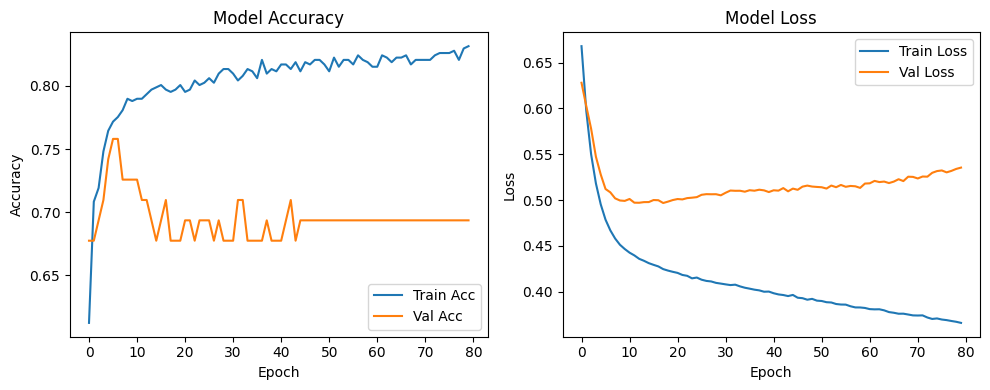

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step

--- Single Prediction (Pima) ---
Sample Data: [  2.  120.   70.   30.   80.   25.    0.5  32. ]
Predicted: Not Diabetic


c:\Users\nazmu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
# URL theke load kora bondho kora holo
# url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

# --- PORIBORTON (MODIFICATION) ---
# Ekhon local file theke load kora hobe.
# Niche apnar local CSV file-er path-ti din.
# (Dhore neya hocche CSV file-ti ei script-er sathe eki folder-e ache)
file_path = "pima-indians-diabetes.csv"
# ---------------------------------

cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']
# df = pd.read_csv(url, names=cols)
df = pd.read_csv(file_path, names=cols) # URL-er poriborte ekhon 'file_path' babohar kora hocche

X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale data
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

# Build ANN model
model = Sequential()
model.add(Dense(16, activation='relu', input_shape=(X_train_sc.shape[1],)))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("--- Model Summary (Pima) ---")
model.summary()
print("\n")

# Train model
history = model.fit(X_train_sc, y_train, epochs=80, batch_size=10, validation_split=0.1, verbose=1)

# Evaluate
y_pred = (model.predict(X_test_sc) > 0.5).astype("int32")
acc = accuracy_score(y_test, y_pred)
print("\n--- Evaluation (Pima) ---")
print("Accuracy:", acc)
print(classification_report(y_test, y_pred))

# Plot accuracy and loss
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Predict a single sample
sample = np.array([[2, 120, 70, 30, 80, 25.0, 0.5, 32]])
sample_sc = sc.transform(sample)
pred = model.predict(sample_sc)
print("\n--- Single Prediction (Pima) ---")
print("Sample Data:", sample[0])
print("Predicted:", "Diabetic" if pred[0][0] > 0.5 else "Not Diabetic")